<a href="https://colab.research.google.com/github/WoojinKim-1/likelion-activities/blob/main/2%E1%84%8C%E1%85%AE%E1%84%8E%E1%85%A1(S).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

실습목표

1. 머신러닝의 기본 흐름 익히기 :
데이터 읽기 -> 문제와 정답 나누기 -> 학습용/시험용 나누기 -> 모델 학습 -> 예측 -> 정확도(적중률) 평가

2. 모델마다 다른 성능 확인 :
똑같은 데이터를 써도 어떤 모델은 더 잘 맞추고, 어떤 모델은 덜 맞추기도 합니다

In [13]:
# 소개팅 애프터 여부 예측 실습

# 데이터 랜덤 생성하기
import pandas as pd
import numpy as np

np.random.seed(42)
n = 200

age_diff = np.random.randint(-5, 6, n)
contact_time = np.random.randint(5,120, n)     # 미션 1. 연락 텀 : 5분 ~ 120분으로 생성해주세요
mbti = np.random.randint(30, 100, n)
tiki_taka = np.random.randint(1, 6, n)


score = (tiki_taka * 15) - (contact_time * 0.2) + (mbti * 0.1)
score += np.random.normal(0, 5, n) # 약간의 운 추가


# 미션 2. 점수가 60점 이상이면 애프터 성공(1), 아니면 실패(0)가 되도록 완성해주세요
after_success = (score >= 60).astype(int)


# 데이터프레임으로 예쁘게 포장하기
df = pd.DataFrame({
    '나이차이': age_diff,
    '연락텀': contact_time,
    'MBTI점수': mbti,
    '티키타카지수': tiki_taka,
    '애프터여부': after_success
})


# CSV 파일로 저장 (인코딩 에러 방지용 utf-8-sig)
df.to_csv('blind_date.csv', index=False, encoding='utf-8-sig')

print("'blind_date.csv' 데이터가 생성되었습니다.")
print(df.head())

'blind_date.csv' 데이터가 생성되었습니다.
   나이차이  연락텀  MBTI점수  티키타카지수  애프터여부
0     1   23      68       3      0
1    -2    6      71       5      1
2     5   57      55       4      1
3     2   48      79       3      0
4    -1   94      54       2      0


In [14]:
# 데이터 분리하기 (학습용 / 테스트용)

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score # 모델의 예측값과 실제값의 잔차

# 미션 3. 위에서 만든 blind_date.csv 데이터를 불러와주세요
df = pd.read_csv('blind_date.csv')

df['애프터여부'].value_counts()
print(df['애프터여부'].value_counts())

#문제와 정답 분리
X = df.drop('애프터여부', axis=1) #axis = 1 정답을 제외
y = df['애프터여부']

# 미션 4. 공부용과 테스트용 데이터로 쪼개기 -> 20%를 테스트용 데이터로 사용 (80% : 20%)
# 데이터를 학습용과 테스트용으로 나눕니다.

# train_test_split 함수는 데이터를 학습용(train)과 테스트용(test)으로 나누는 함수입니다.

# X_train : 학습용 문제 데이터 (모델이 학습할 때 사용)
# X_test  : 테스트용 문제 데이터 (모델이 테스트 할 때 사용)
# y_train : 학습용 정답 데이터
# y_test  : 테스트용 정답 데이터

# X = 문제
# y = 정답

# test_size=0.2는 전체 데이터의 20%를 테스트용으로 사용한다는 뜻입니다.
# random_state=42를 설정하면 실행할 때마다 같은 방식으로 나뉘어 결과 비교가 쉬워집니다.
# 식을 완성해주세요
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

애프터여부
0    146
1     54
Name: count, dtype: int64


여러 모델 중 여러분이 원하시는 모델을 사용해보세요

모델이 예측을 해보고 실제 정답과 비교해봤을 때의 적중률이 각각 다른 것을 확인할 수 있습니다. 어떤 모델이 가장 적중률이 높나요?

In [20]:
# 1번 후보: 로지스틱 회귀 (과제)
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression()

# 미션 5. fit() 함수는 모델을 학습시키는 함수입니다.
# X_train = 학습용 문제 데이터
# y_train = 학습용 정답 데이터
# 함수를 완성해주세요
model_lr.fit(X_train, y_train)     #fit()을 통해 컴퓨터가 규칙을 학습

pred_lr = model_lr.predict(X_test)
acc_lr = accuracy_score(y_test, pred_lr)

print(f"1. 로지스틱 회귀 적중률: {acc_lr * 100:.1f}%")

1. 로지스틱 회귀 적중률: 95.0%


In [29]:
#Decision Tree (비지도 학습)
from sklearn.tree import DecisionTreeClassifier

# 미션 6. max_depth는 트리가 몇 단계까지 깊어질 수 있는지 정하는 값입니다. 트리 단계를 3으로 제한해주세요.
model_dt = DecisionTreeClassifier(max_depth=3, random_state=42)

model_dt.fit(X_train, y_train)
pred_dt = model_dt.predict(X_test)
acc_dt = accuracy_score(y_test, pred_dt) #잔차 확인

print(f"2. 결정 트리 적중률: {acc_dt * 100:.1f}%")

2. 결정 트리 적중률: 92.5%


In [22]:
#랜덤 포레스트
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train)

# 미션 7. predict() 함수는 학습이 끝난 모델이 테스트용 문제(X_test)를 보고 결과를 예측하는 단계입니다. 함수를 완성해주세요
pred_rf = model_rf.predict(X_test)

acc_rf = accuracy_score(y_test, pred_rf)

print(f"3. 랜덤 포레스트 적중률: {acc_rf * 100:.1f}%")

3. 랜덤 포레스트 적중률: 95.0%


In [23]:
# XgBoost
from xgboost import XGBClassifier

model_xgb = XGBClassifier(random_state=42)
model_xgb.fit(X_train, y_train)
pred_xgb = model_xgb.predict(X_test)

# 미션 8. accuracy_score()는
# 실제 정답(y_test)과 모델이 예측한 값(pred_xgb)을 비교해서 얼마나 많이 맞췄는지 계산하는 함수입니다. 함수를 완성해주세요
acc_xgb = accuracy_score(y_test,pred_xgb)

print(f"4. XGBoost 적중률: {acc_xgb * 100:.1f}%\n")

4. XGBoost 적중률: 95.0%



In [26]:
# 한글 폰트 깨짐 방지 세팅
import matplotlib.pyplot as plt
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf
plt.rc('font', family='NanumBarunGothic')

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 6 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

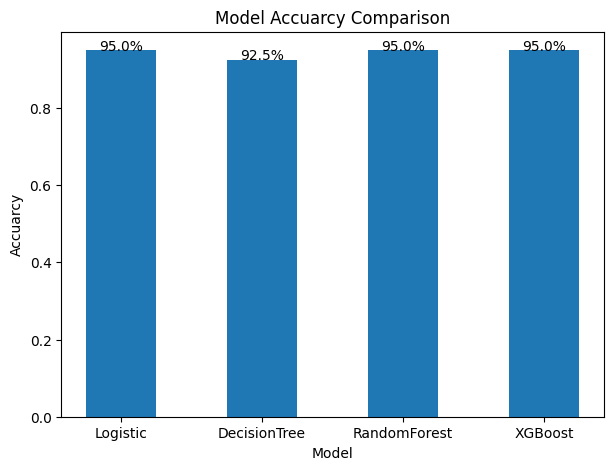

In [28]:
import matplotlib.pyplot as plt

# 모델 이름
models = ['Logistic', 'DecisionTree', 'RandomForest', 'XGBoost']

# 각 모델 정확도
scores = [acc_lr, acc_dt, acc_rf, acc_xgb]

# 미션 9: 그래프 사이즈를 가로 7, 세로 5으로 넓게 펴주세요.
plt.figure(figsize=(7,5))

# 막대 그래프 생성
plt.bar(models, scores, width=0.5)

# 미션 10: x축은 '모델', y축은 '적중률'로 막대그래프를 그려보세요.
plt.title('Model Accuarcy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuarcy')

for i, v in enumerate(scores):
    plt.text(i, v, f"{v*100:.1f}%", ha='center')

# 그래프 출력
plt.show()